In [126]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from parameters import *
from data import * 

In [136]:
with open("../data/user_interaction_log.json", "r") as f:
    data = json.load(f)
    profile = data["user_profile"]
    interactions = data["interactions"]
with open("../data/dummy_feed.json", "r") as f:
    properties = json.load(f)

In [137]:
from generators.score import *

now = datetime.now()
prop_map = {p["id"]: p for p in properties}

interaction_count = len(interactions)
alpha, beta = compute_alpha_beta(interaction_count)
user_vec = build_user_vector(interactions, properties)
session_ctx = build_session_context(interactions)

implicit_map = {p["id"]: 0.0 for p in properties}
session_map = {p["id"]: 0.0 for p in properties}

In [138]:
for event in interactions:
    pid = event["listing_id"]
    if pid not in prop_map: continue
    dt = (now - datetime.fromisoformat(event["timestamp"])).total_seconds() / 3600
    d_i = compute_di(event["dwell_time_sec"], event["activity_factor"])

    implicit_map[pid] += event["weight"] * d_i * np.exp(-LAMBDA_HISTORICAL * dt)
    match_score = compute_match_score(event, session_ctx) 
    session_map[pid] += event["weight"] * match_score * d_i * np.exp(-LAMBDA_SESSION * dt)

results = []
epsilon = EPSILON_NEW_USER if interaction_count < 20 else EPSILON_OLD_USER

for p in properties:
    pid = p["id"]
    p_vec = build_property_vector(p)
    post_age = (now - datetime.fromisoformat(p["created_at"])).total_seconds() / 3600

    explicit = np.dot(user_vec, p_vec) * compute_distance_score(profile["target_lat"], profile["target_lng"], p["lat"], p["lng"])

    implicit = np.tanh(implicit_map[pid])
    session = np.tanh(session_map[pid])

    rel_final = compute_relevance_final(explicit, implicit, session, alpha, beta)
    freshness = compute_freshness(post_age)
    B = compute_B(p["authority"])

    score_raw = compute_raw_rank_score(rel_final, freshness, B, post_age)
    score_bubble = apply_anti_bubble(score_raw, epsilon)

    results.append({
        "id": pid,
        "property_type": p["property_type"],
        "score_before_log": score_bubble,
        "explicit": explicit,
        "implicit": implicit_map[pid],
        "session": session_map[pid],
        "freshness": freshness,
        "B": B
    })

results.sort(key=lambda x: x["score_before_log"], reverse=True)
results = apply_diversity_penalty(results)
results = percentile_normalize(results)

results = pd.DataFrame(results)
results.head(10)

,id,property_type,score_before_log,explicit,implicit,session,freshness,B,final_score_log,norm_score
0,0ed96939,material,4.625203,1.198378e-01,27.487660,1.054012e+01,0.763113,2.169206,1.727257,1.000000
1,a40d7e00,house,4.364106,6.926677e-06,8.291372,2.792025e-06,0.117778,2.391840,1.679730,0.998999
2,e27dd27b,construction,4.307287,2.151399e-05,0.935274,8.019824e-10,0.978579,2.274195,1.669081,0.997998
3,2413d6b7,land,4.238113,2.960079e-07,2.731742,2.139624e-02,0.325293,2.239801,1.655961,0.996997
4,197799ce,condo,4.174762,5.789726e-07,0.533963,1.678757e-09,0.107742,2.211618,1.643793,0.995996
5,d20485db,apartment,3.219791,5.817899e-11,0.913263,1.988030e-19,0.919901,1.179743,1.439786,0.994995
6,4d476003,material,2.207609,9.337173e-07,3.558147,1.640427e-01,0.704148,2.326883,1.165526,0.993994
7,a5c3cfcc,construction,2.092643,2.084495e-05,1.389750,2.602355e-07,0.703315,2.161378,1.129026,0.992993
8,43cc6893,condo,1.983647,9.620764e-07,0.454035,5.977756e-04,0.337924,1.983330,1.093147,0.991992
9,71abb404,house,1.982031,4.142675e-11,1.199860,5.447911e-13,0.236997,1.983536,1.092605,0.990991


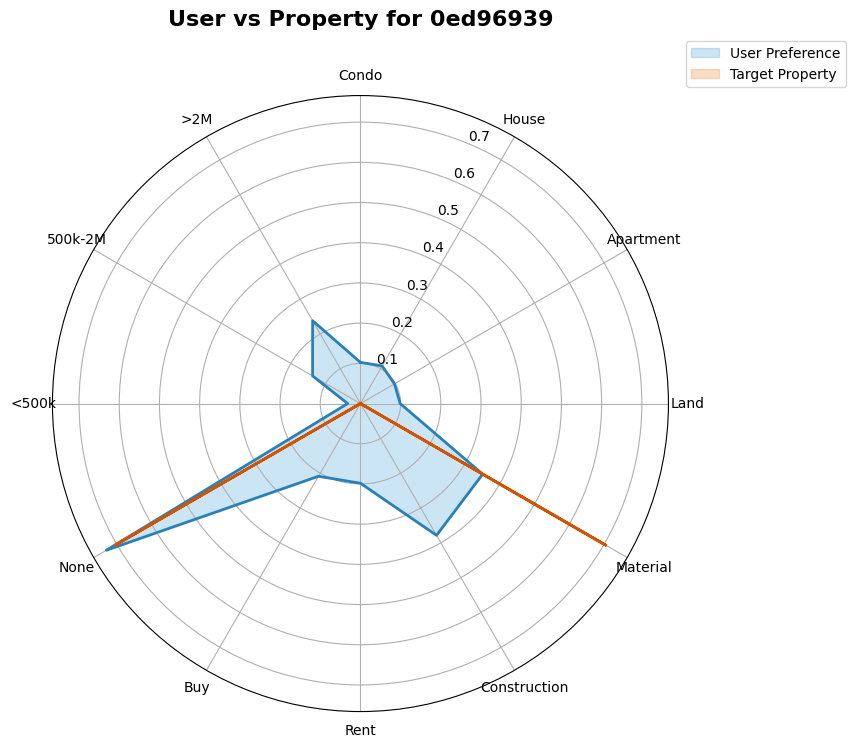

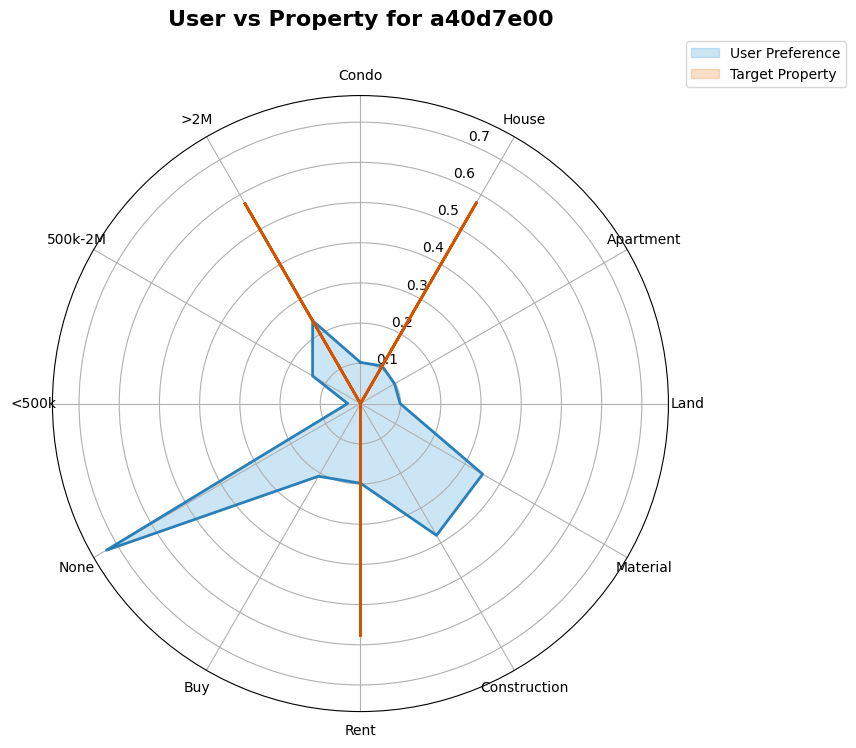

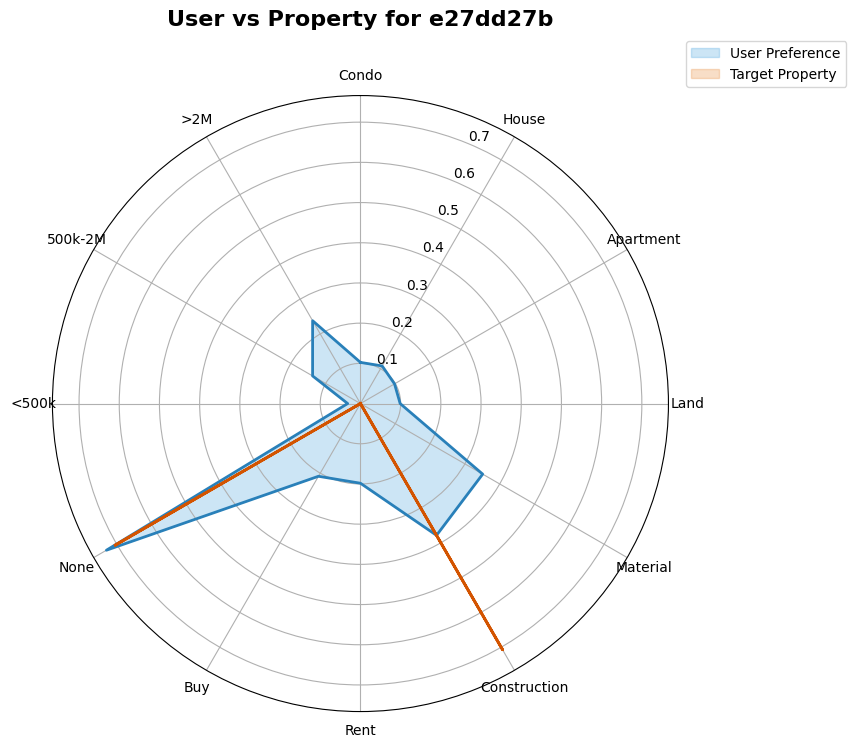

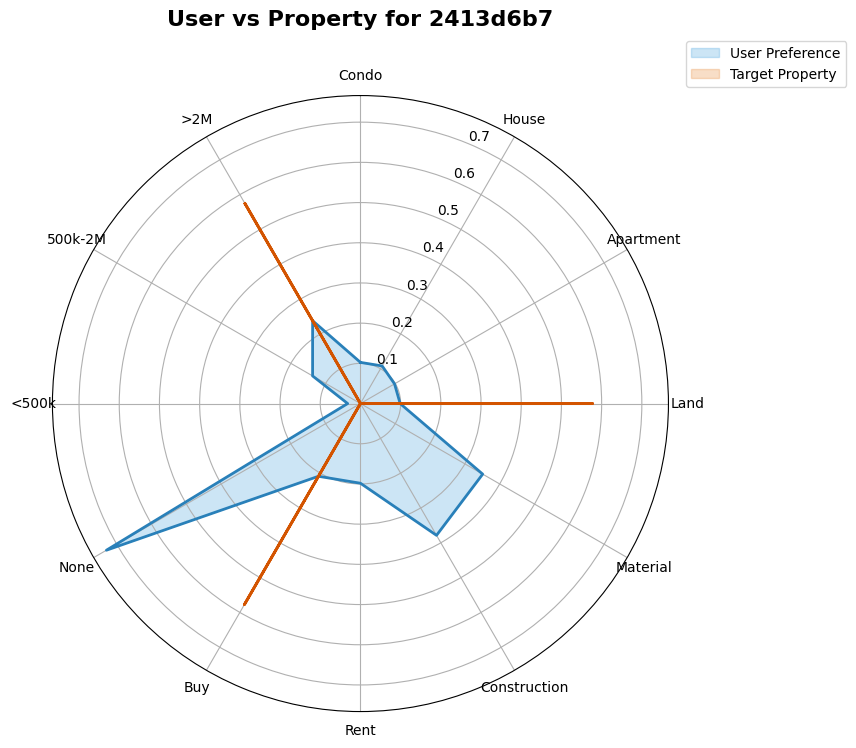

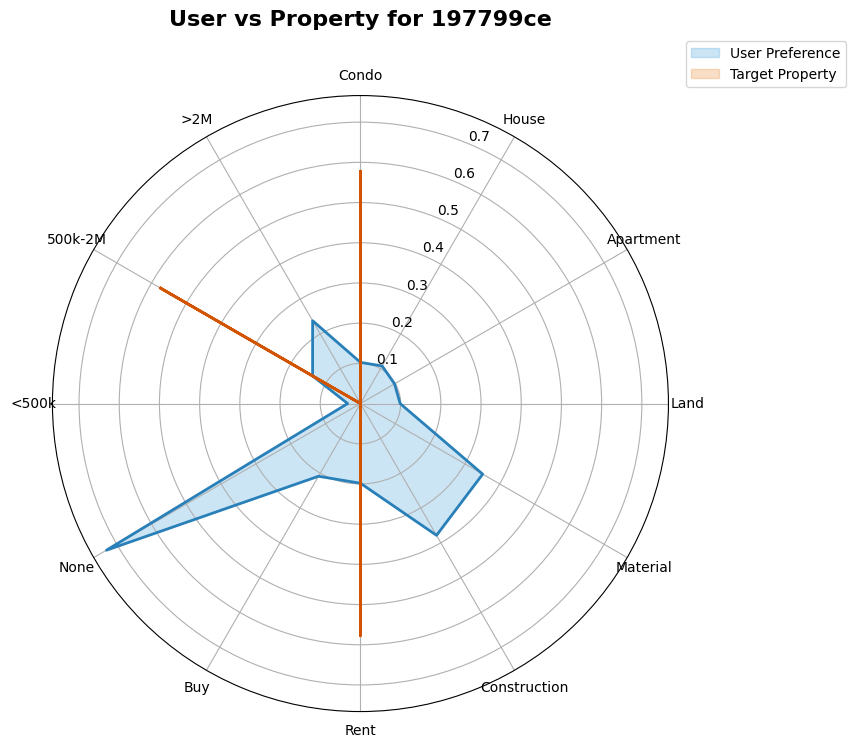

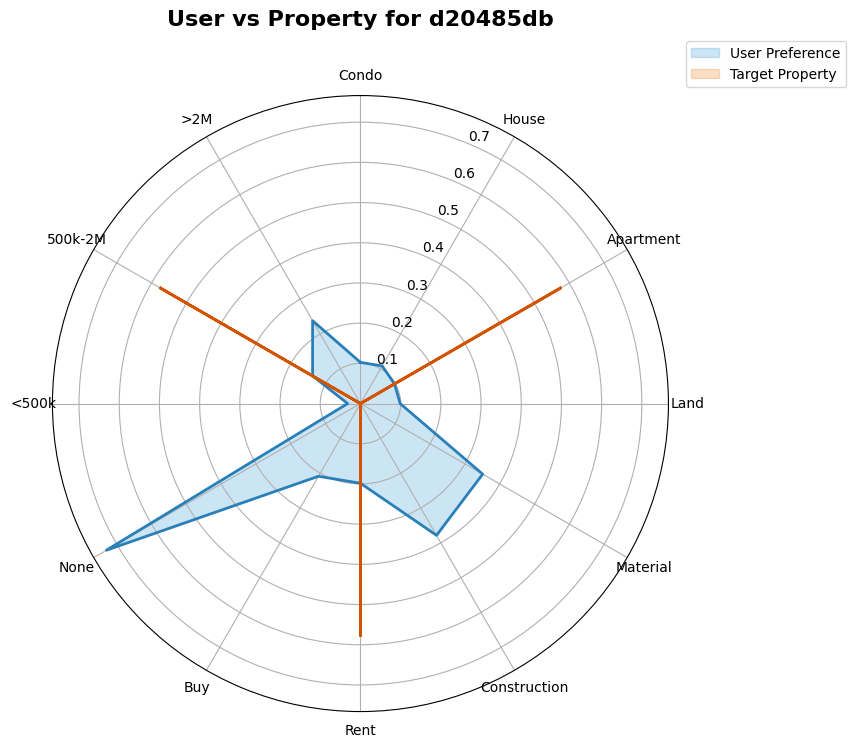

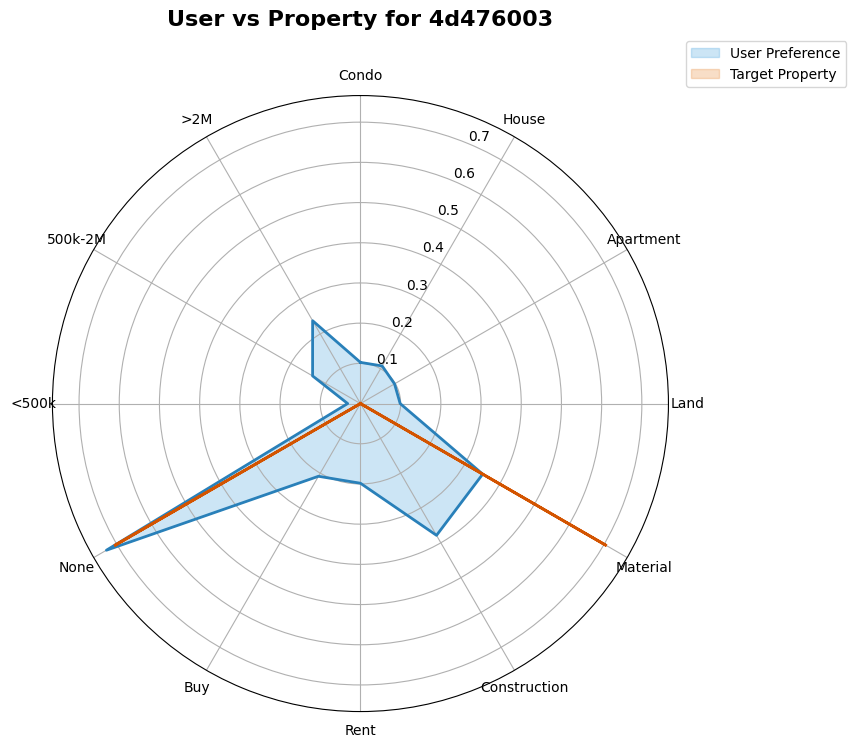

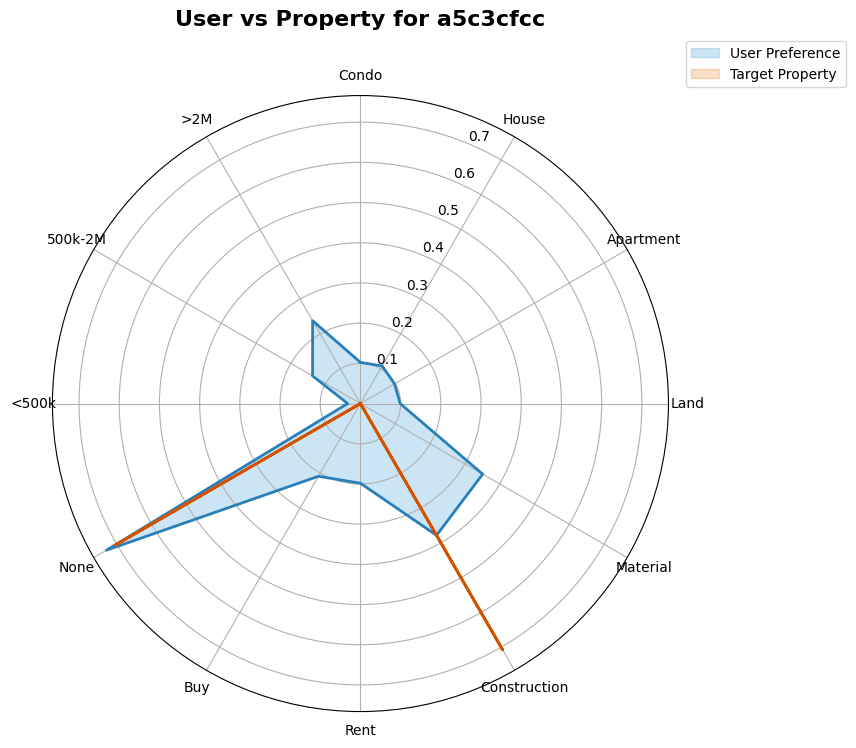

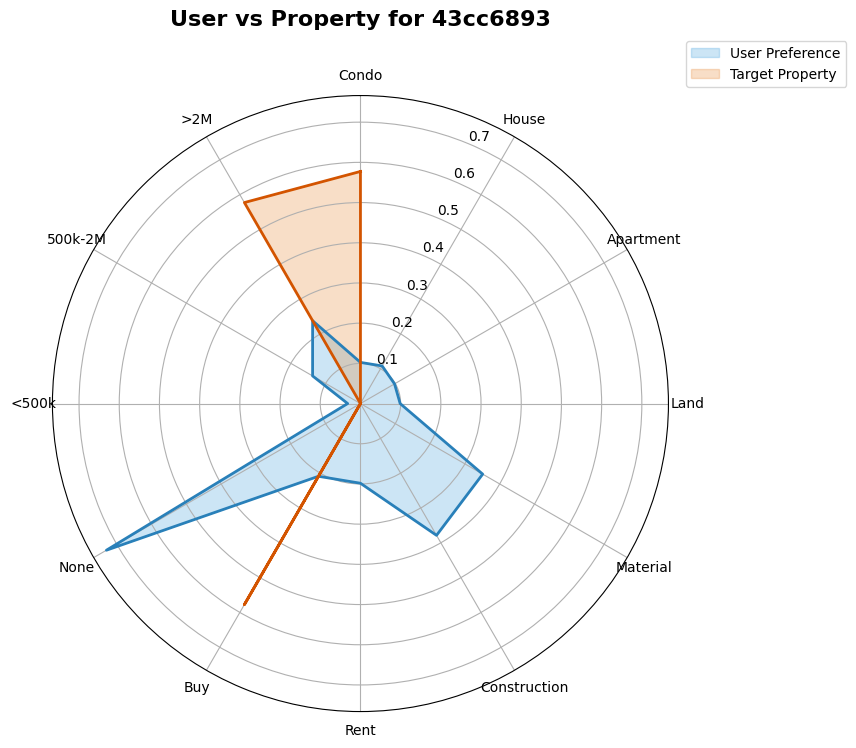

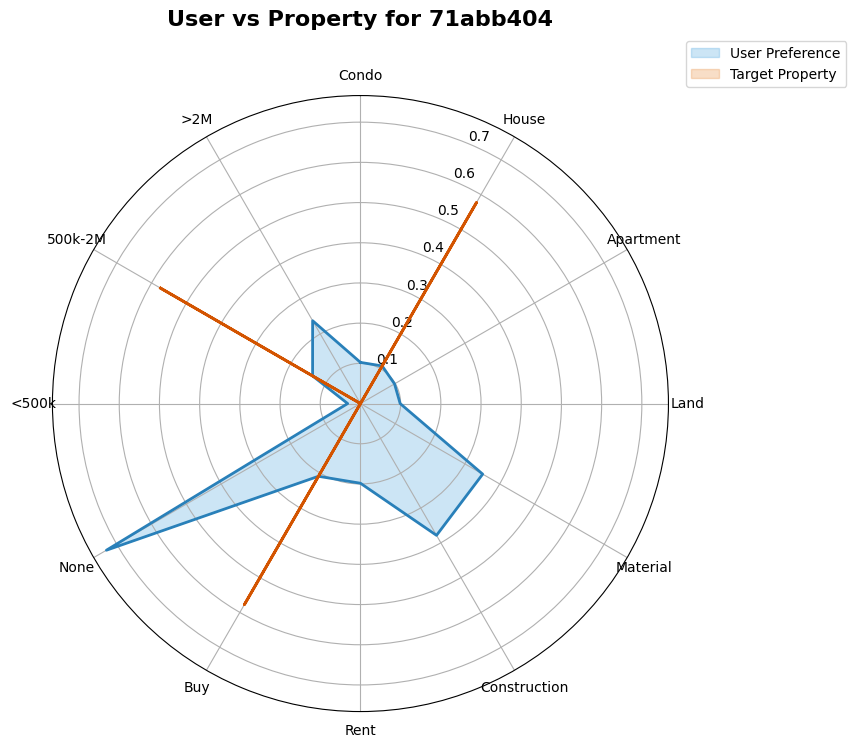

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your labels (must match your 12D vector order)
labels = [
    'Condo', 'House', 'Apartment', 'Land', 'Material', 'Construction', 
    'Rent', 'Buy', 'None', '<500k', '500k-2M', '>2M'
]

def plot_sunfire_radar(user_vec, prop_vec, title):
    num_vars = len(labels)
    
    # Calculate angles for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # "Close" the loop for the radar chart
    angles += angles[:1]
    user_vec = np.append(user_vec, user_vec[0])
    prop_vec = np.append(prop_vec, prop_vec[0])

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Plot User Vector (The Blueprint)
    ax.fill(angles, user_vec, color='#3498db', alpha=0.25, label='User Preference')
    ax.plot(angles, user_vec, color='#2980b9', linewidth=2)

    # Plot Property Vector (The Reality)
    ax.fill(angles, prop_vec, color='#e67e22', alpha=0.25, label='Target Property')
    ax.plot(angles, prop_vec, color='#d35400', linewidth=2)

    # Aesthetics
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Fix labels to axes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)
    
    # Add legend and title
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(title, size=16, y=1.1, fontweight='bold')
    
user_v = build_user_vector(interactions, properties)
for i in results.head(10).values:
    for p in properties:
        if p["id"] == i[0]:
            prop_v = build_property_vector(p)
            plot_sunfire_radar(user_v, prop_v, f"User vs Property for {i[0]}")

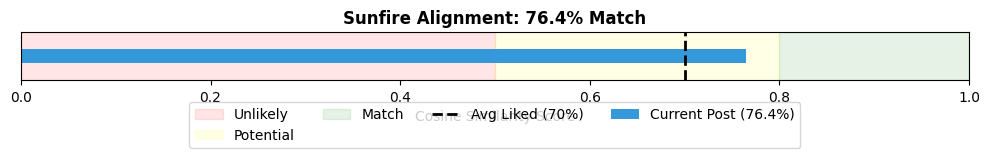

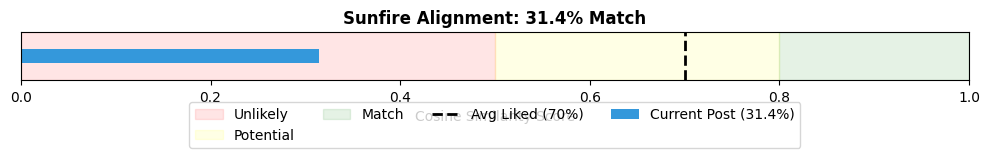

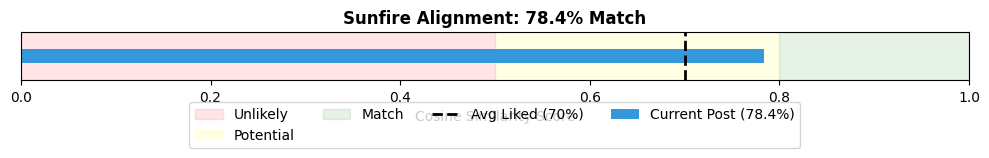

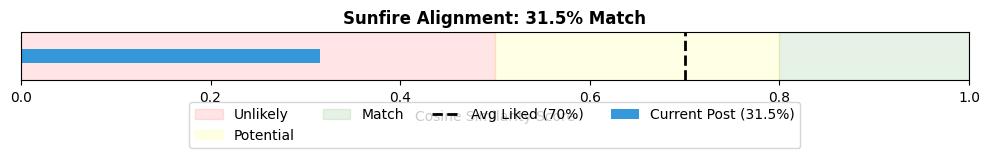

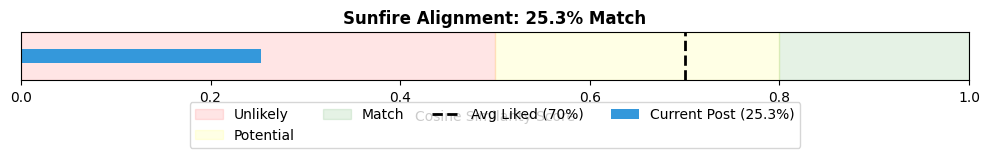

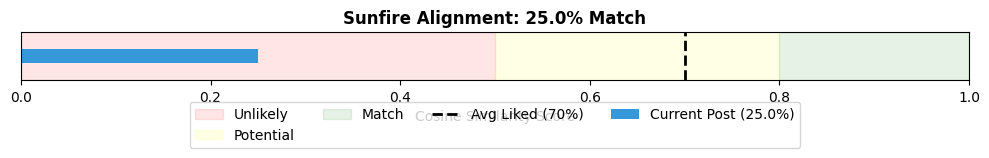

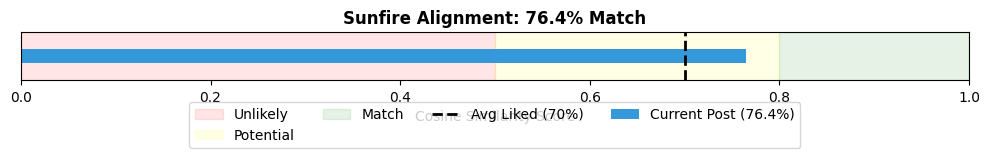

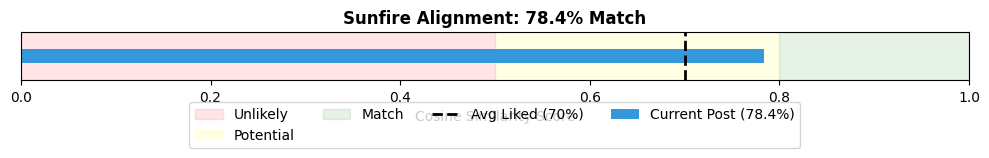

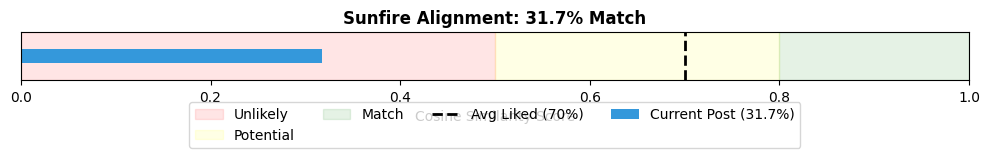

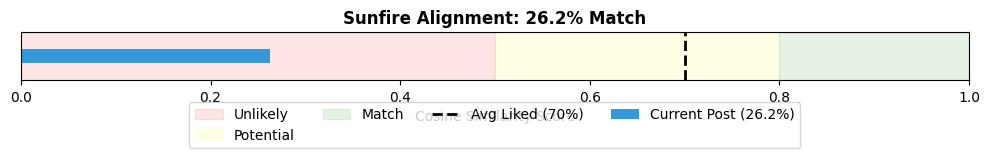

In [140]:
def visualize_similarity(user_vec, prop_vec, avg_sim=0.70):
    # 1. Calculate Cosine Similarity
    dot_product = np.dot(user_vec, prop_vec)
    norm_user = np.linalg.norm(user_vec)
    norm_prop = np.linalg.norm(prop_vec)
    
    similarity = dot_product / (norm_user * norm_prop) if (norm_user * norm_prop) > 0 else 0

    # 2. Setup the Plot
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # Background "Vibe Zones"
    ax.axvspan(0, 0.5, color='red', alpha=0.1, label='Unlikely')
    ax.axvspan(0.5, 0.8, color='yellow', alpha=0.1, label='Potential')
    ax.axvspan(0.8, 1.0, color='green', alpha=0.1, label='Match')

    # The User's Average Liked Similarity (The Baseline)
    ax.axvline(avg_sim, color='black', linestyle='--', linewidth=2, label=f'Avg Liked ({avg_sim*100:.0f}%)')

    # The Current Post's Similarity
    ax.barh(0.5, similarity, height=0.3, color='#3498db', label=f'Current Post ({similarity*100:.1f}%)')

    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel('Cosine Similarity Score')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=4)
    plt.title(f"Sunfire Alignment: {similarity*100:.1f}% Match", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

user_v = build_user_vector(interactions, properties)
for i in results.head(10).values:
    for p in properties:
        if p["id"] == i[0]:
            prop_v = build_property_vector(p)
            visualize_similarity(user_v, prop_v, avg_sim=0.70)

[np.float64(0.7642727009327844), np.float64(0.31418113825229665), np.float64(0.7836439689122257), np.float64(0.31499862410328405), np.float64(0.2529230137228726), np.float64(0.2503283847175648), np.float64(0.7642727009327844), np.float64(0.7836439689122257), np.float64(0.3170956530253821), np.float64(0.2623418724407705)]


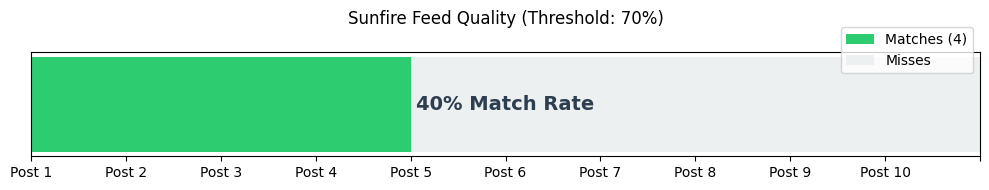

In [141]:
def visualize_feed_density(scores, threshold=0.70):
    # 1. Calculate how many are "Hits" (Match >= 70%)
    matches = [1 if s >= threshold else 0 for s in scores]
    num_matches = sum(matches)
    match_percentage = (num_matches / len(scores)) * 100

    # 2. Setup the visualization (Stacked Horizontal Bar)
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # Plot the "Matches" vs "Misses"
    ax.barh(0, num_matches, color='#2ecc71', label=f'Matches ({num_matches})')
    ax.barh(0, len(scores) - num_matches, left=num_matches, color='#ecf0f1', label=f'Misses')

    # Add a center text for the percentage
    plt.text(len(scores)/2, 0, f"{match_percentage:.0f}% Match Rate", 
             ha='center', va='center', fontsize=14, fontweight='bold', color='#2c3e50')

    # Formatting the "Feed" look
    ax.set_xlim(0, len(scores))
    ax.set_xticks(range(len(scores) + 1))
    ax.set_xticklabels([f"Post {i+1}" if i < len(scores) else "" for i in range(len(scores) + 1)])
    ax.set_yticks([])
    
    plt.title(f"Sunfire Feed Quality (Threshold: {threshold*100:.0f}%)", pad=20)
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1.3))
    plt.tight_layout()
    plt.show()

feed_scores = []

for i in results.head(10).values:
    for p in properties:
        if p["id"] == i[0]:
            prop_v = build_property_vector(p)
            val = np.dot(user_v, prop_v)
            feed_scores.append(val)
print(feed_scores)
visualize_feed_density(feed_scores, threshold=0.70)